## MNIST handwritten digits (28×28 grayscale images, 0–9)

### Load Dataset

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

### Train-Test split

In [ ]:
# Normalize images (scale pixel values to [0, 1])
x_train, x_test = x_train / 255.0, x_test / 255.0

# Flatten images (28x28 to 784)
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

### Network defining

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),  # hidden layer
    Dense(10, activation='softmax')  # output layer (10 classes)
])

c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### model Compilation

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### Model training

In [6]:
history = model.fit(x_train, y_train, 
                    epochs=5, 
                    batch_size=32, 
                    validation_split=0.1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9227 - loss: 0.2714 - val_accuracy: 0.9675 - val_loss: 0.1242
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9635 - loss: 0.1243 - val_accuracy: 0.9733 - val_loss: 0.0998
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9740 - loss: 0.0869 - val_accuracy: 0.9743 - val_loss: 0.0938
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9807 - loss: 0.0647 - val_accuracy: 0.9790 - val_loss: 0.0760
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9845 - loss: 0.0513 - val_accuracy: 0.9788 - val_loss: 0.0770


### Model Evaluation

In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9767 - loss: 0.0801
Test accuracy: 0.9767000079154968
Test loss: 0.0800938606262207


### Taining vs Validation Accuracy

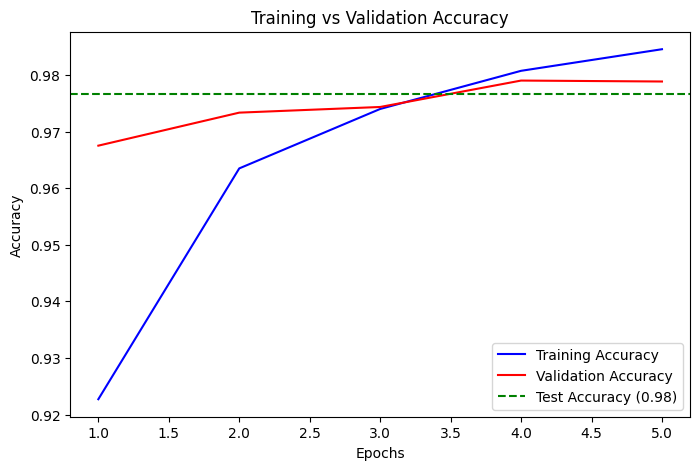

In [ ]:
import matplotlib.pyplot as plt

train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')

# Mark the final test accuracy
plt.axhline(y=test_acc, color='g', linestyle='--', label=f'Test Accuracy ({test_acc:.2f})')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
